<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_02_Predictive_Maintenance_Industrial_IOT/Project_02_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries for data processing, machine learning, and visualization
import pandas as pd
import numpy as np
import math
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

In [2]:
# Load the sensor data from CSV and drop rows with missing values
sensor_data = pd.read_csv("/content/sensor.csv")
sensor_data = sensor_data.dropna()
print(sensor_data)

            ID  sensor_00  sensor_01  sensor_02  sensor_03  sensor_04  \
0            1   2.465394  47.092010   53.21180  46.310760   634.3750   
1            2   2.465394  47.092010   53.21180  46.310760   634.3750   
2            3   2.444734  47.352430   53.21180  46.397570   638.8889   
3            4   2.460474  47.092010   53.16840  46.397568   628.1250   
4            5   2.445718  47.135410   53.21180  46.397568   636.4583   
...        ...        ...        ...        ...        ...        ...   
143313  143314   2.474248  45.138886   51.86632  46.440970   636.5741   
143314  143315   2.476215  45.138890   51.86632  46.440971   621.7593   
143315  143316   2.468345  45.182290   51.82291  46.440971   626.2731   
143316  143317   2.479167  45.138890   51.86632  46.440971   631.9445   
143317  143318   2.466377  45.138886   51.86632  46.440971   630.9028   

        sensor_05  sensor_06  sensor_07  sensor_08  ...  sensor_43  sensor_44  \
0        76.45975   13.41146   16.13136   

In [3]:
# Define independent and dependent variables from the sensor data columns
col_names = sensor_data.columns
indep_vars= col_names[1:52]
depep_Vars = col_names[52]

In [5]:
# Split the data into training and testing sets
X = sensor_data[indep_vars]
y = sensor_data[depep_Vars]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [6]:
# Initialize, train, and make predictions with a Decision Tree Classifier
clf = DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [7]:
# Calculate and display the confusion matrix for the model's predictions
metrics.confusion_matrix(y_test, y_pred, labels=None, sample_weight=None )

array([[23285,     4],
       [    5,   526]])

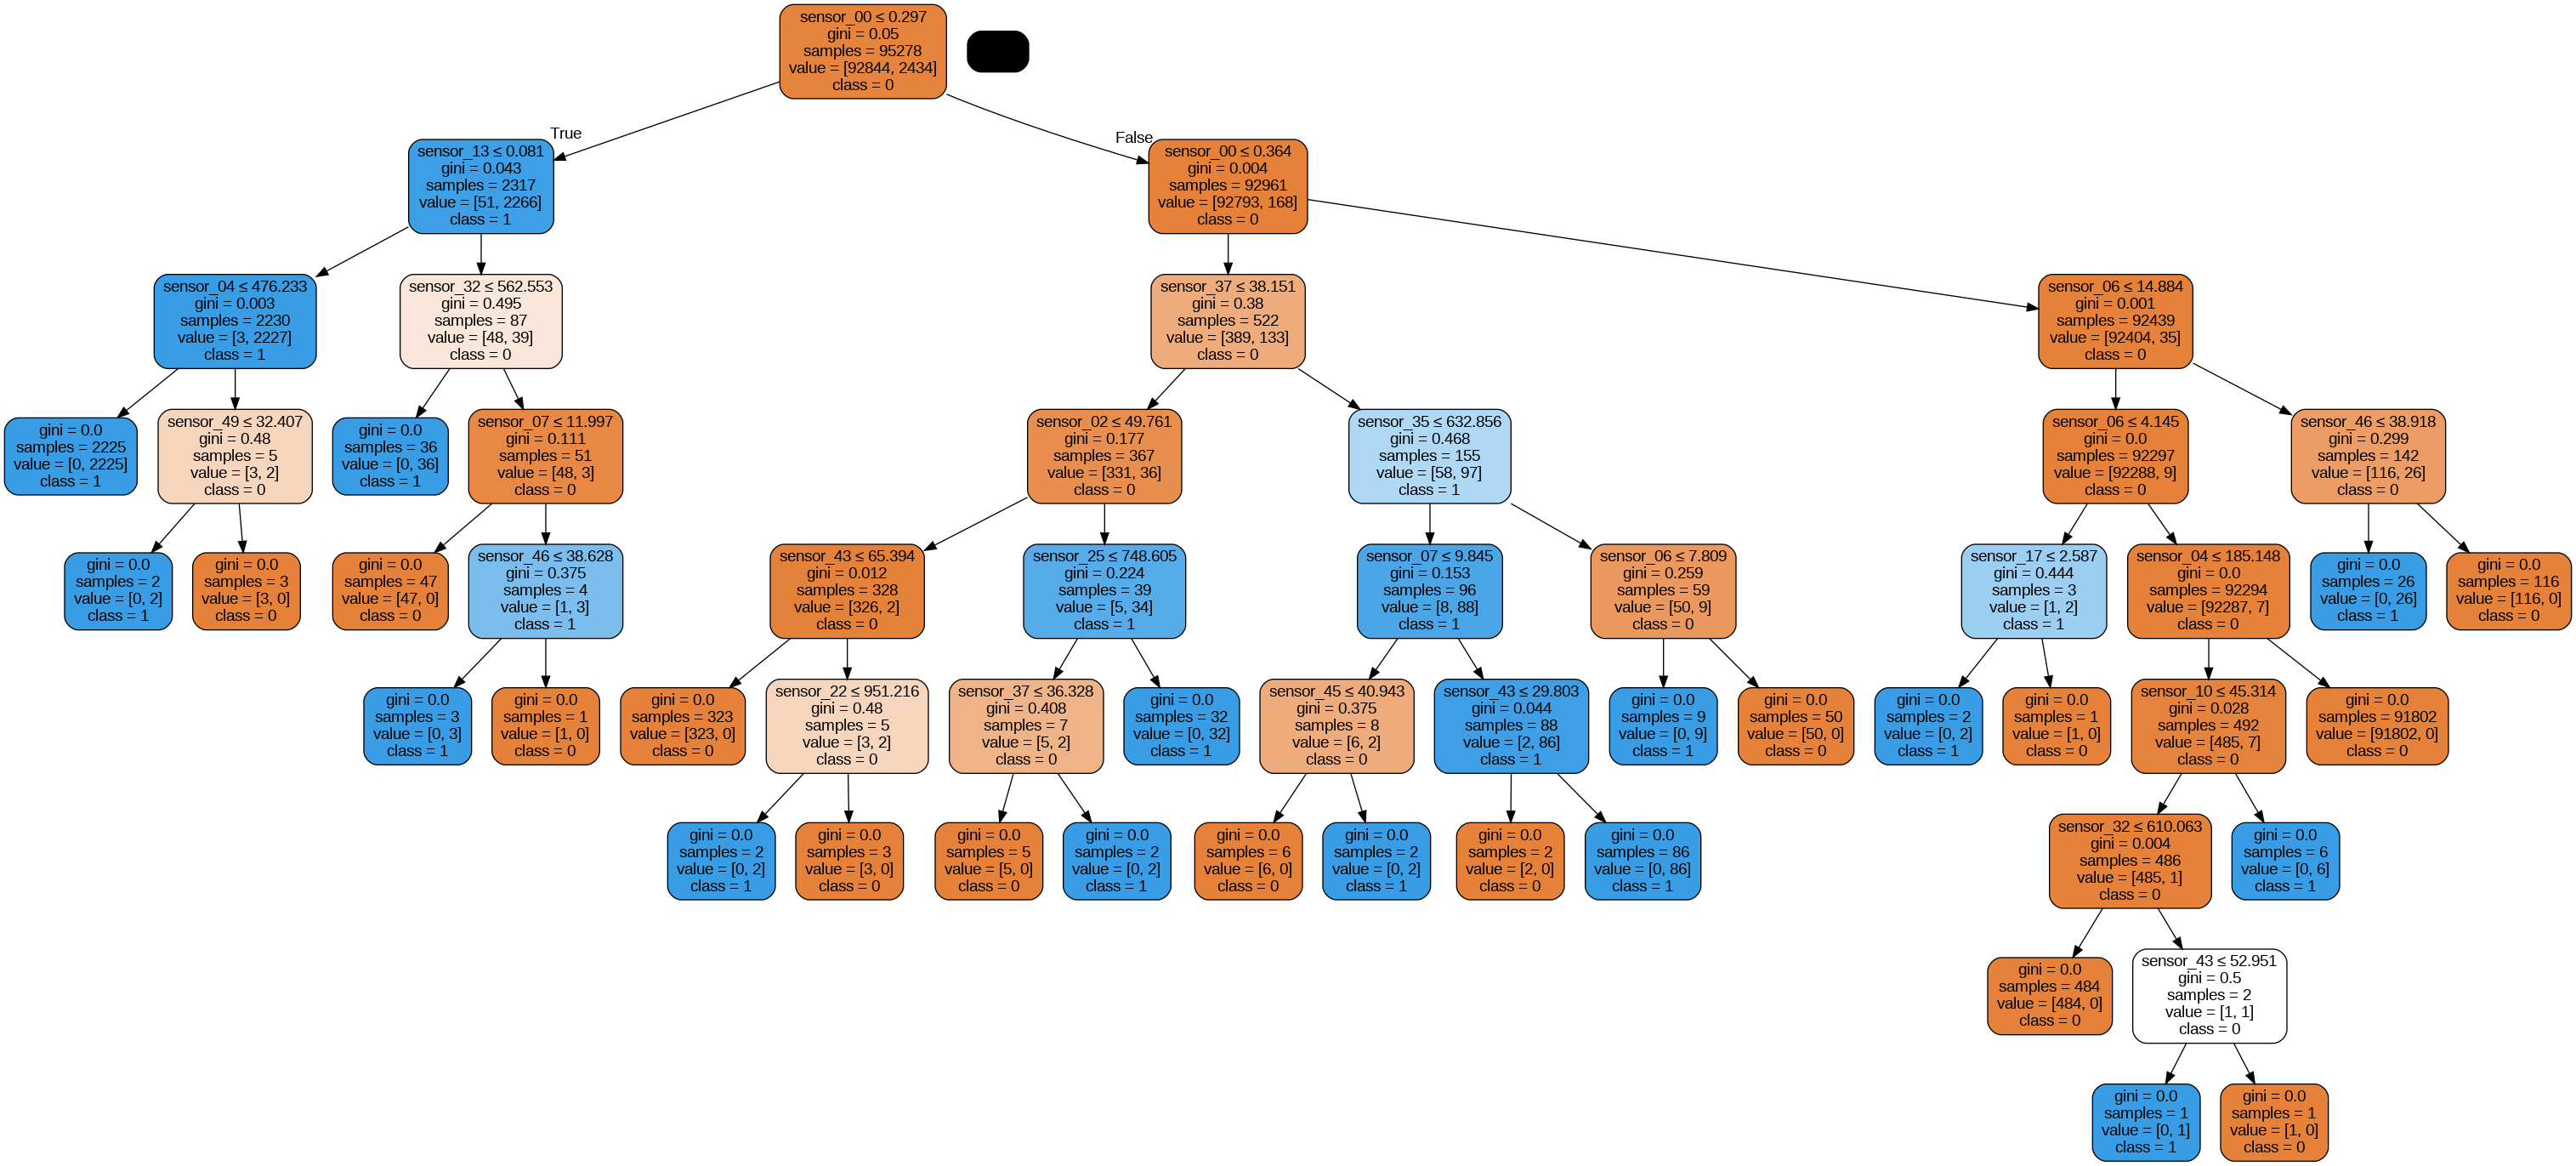

In [8]:
# Visualize the trained Decision Tree Classifier and save it as a PNG image
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = indep_vars,class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())